In [55]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

In [56]:
dataset_path = "dataset/flowers"

images = []
labels = []
image_paths = []   # Tambahan

In [57]:
# Membaca semua folder kelas
for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    # Pastikan yang dibaca adalah folder
    if os.path.isdir(folder_path):

        # Membaca semua gambar dalam folder
        for file in os.listdir(folder_path):

            file_path = os.path.join(folder_path, file)

            # Membaca gambar
            img = cv2.imread(file_path)

            # Jika gambar berhasil dibaca
            if img is not None:

                # Resize gambar menjadi 64x64
                img = cv2.resize(img, (64, 64))

                # Simpan gambar
                images.append(img)

                # Simpan nama kelas
                labels.append(folder)

                image_paths.append(file_path)

In [58]:
print("Jumlah gambar :", len(images))
print("Jumlah label :", len(labels))

Jumlah gambar : 4317
Jumlah label : 4317


In [59]:
# Mengubah list menjadi array NumPy
X = np.array(images)
y = np.array(labels)

In [60]:
print("Bentuk X :", X.shape)
print("Bentuk y :", y.shape)

Bentuk X : (4317, 64, 64, 3)
Bentuk y : (4317,)


In [61]:
# Mengubah gambar menjadi 1 dimensi
X = X.reshape(X.shape[0], -1)

In [62]:
print("Bentuk X setelah Flatten :", X.shape)

Bentuk X setelah Flatten : (4317, 12288)


In [63]:
# Mengubah label menjadi angka
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [64]:
print("5 Label pertama :", y[:5])

5 Label pertama : [0 0 0 0 0]


In [65]:
# Normalisasi data
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [66]:
# Membagi data menjadi data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=24146074
)

In [67]:
print("Jumlah data training :", X_train.shape)
print("Jumlah data testing  :", X_test.shape)

Jumlah data training : (3453, 12288)
Jumlah data testing  : (864, 12288)


In [68]:
# Membuat model Multi-Layer Perceptron
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=300,
    random_state=24146074
)

In [69]:
# Melatih model
mlp.fit(X_train, y_train)

,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",24146074
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [70]:
# Melakukan prediksi
y_pred = mlp.predict(X_test)

In [71]:
# Menghitung akurasi
accuracy = accuracy_score(y_test, y_pred)

print("Akurasi Model :", accuracy)

Akurasi Model : 0.45023148148148145


In [72]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.37      0.37      0.37       155
           1       0.47      0.52      0.49       210
           2       0.41      0.41      0.41       155
           3       0.54      0.59      0.56       141
           4       0.46      0.37      0.41       203

    accuracy                           0.45       864
   macro avg       0.45      0.45      0.45       864
weighted avg       0.45      0.45      0.45       864



In [73]:
import random

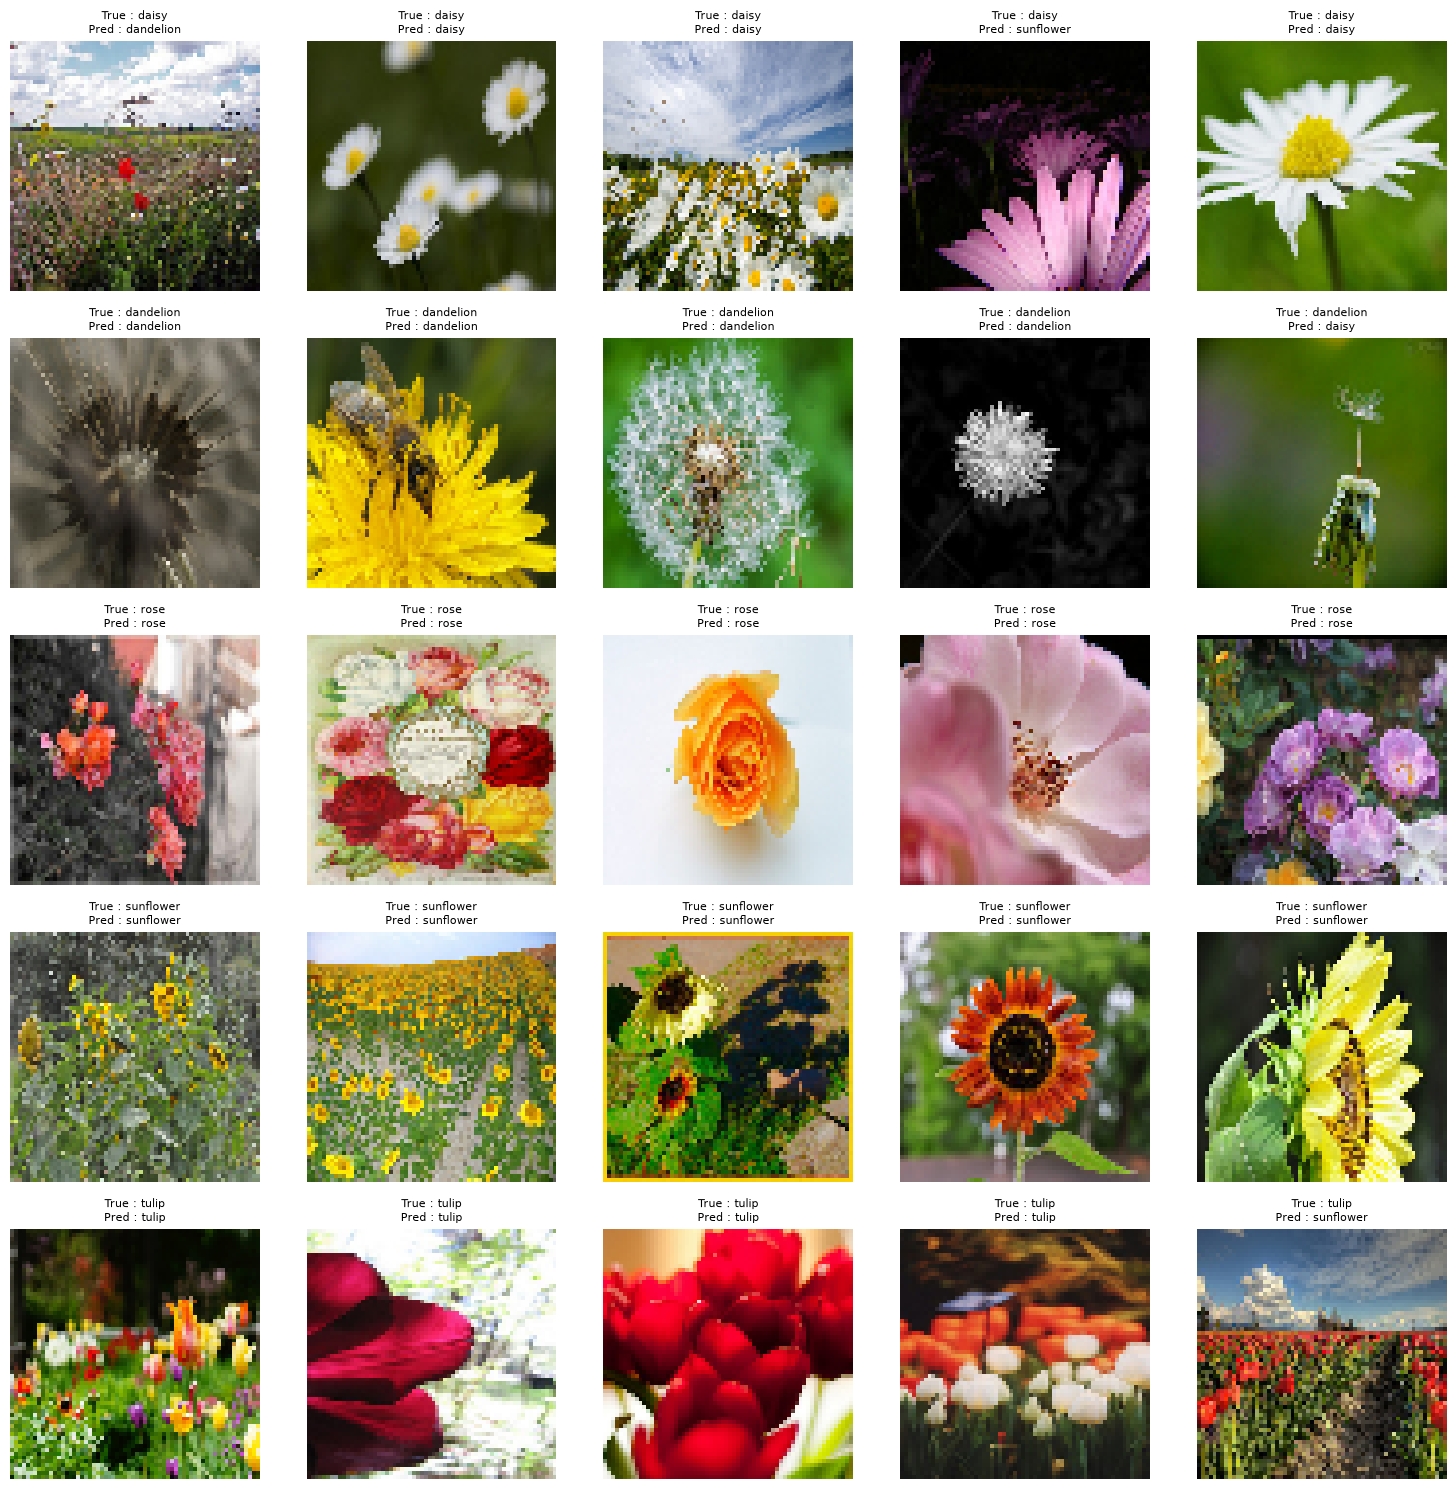

In [74]:
# Menampilkan 5 gambar acak dari setiap kelas
kelas = label_encoder.classes_

plt.figure(figsize=(15, 15))

nomor = 1

for i, nama_kelas in enumerate(kelas):

    # Mencari indeks gambar sesuai kelas
    indeks = [j for j, label in enumerate(labels) if label == nama_kelas]

    # Mengambil 5 gambar secara acak
    sampel = random.sample(indeks, 5)

    for idx in sampel:

        # Membaca kembali gambar asli
        img = cv2.imread(image_paths[idx])

        # Mengubah ukuran
        img = cv2.resize(img, (64, 64))

        # Menyiapkan data untuk diprediksi
        data = img.reshape(1, -1)
        data = scaler.transform(data)

        # Prediksi
        prediksi = mlp.predict(data)

        # Menampilkan gambar
        plt.subplot(5, 5, nomor)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

        plt.title(
            f"True : {nama_kelas}\nPred : {kelas[prediksi[0]]}",
            fontsize=8
        )

        plt.axis("off")

        nomor += 1

plt.tight_layout()
plt.show()